# Notebook 09 - Final Insights and Business Integration

## Overview

This notebook integrates all outputs from the project pipeline into a unified business view. It demonstrates that the analyses completed across Notebooks 01 - 08 can be operationalised to support real retail business decisions.

### Project Pipeline Summary

| Notebook | Step | Output |
|----------|------|--------|
| 01 | Data Loading | Raw dataset overview |
| 02 | Data Cleaning | 392,578 clean transactions |
| 03 | EDA | Revenue trends, customer concentration, seasonality |
| 04 | Feature Engineering | RFM features for 4,331 customers |
| 05 | Segmentation | 3 customer segments via K-Means |
| 06 | Recommendations | Product association rules via Apriori |
| 07 | Model Training | Logistic Regression (83% accuracy) |
| 08 | Model Evaluation | Confusion matrix, ROC, F1, feature importance |
| **09** | **Integration** | **Business insights, recommendations, ethics** |

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

plt.rcParams['figure.dpi'] = 100
print("Libraries loaded.")

Libraries loaded.


## Step 1: Load All Previous Outputs

In [13]:
# Customer segments with RFM
segments = pd.read_csv("customer_segments.csv", index_col=0)

# Product association rules
rules = pd.read_csv("recommendations.csv")

# Trained model
model = joblib.load("model.pkl")

print(f"Segments loaded:      {len(segments):,} customers")
print(f"Association rules:    {len(rules):,} rules")
print(f"Model loaded:         {type(model).__name__}")
segments.head()

Segments loaded:      4,331 customers
Association rules:    134 rules
Model loaded:         LogisticRegression


,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12347,1,7,4310.00,0,Regular Customers
12348,74,4,1797.24,0,Regular Customers
12349,18,1,1757.55,0,Regular Customers
12350,309,1,334.40,2,Low-Value Customers
12352,35,8,2506.04,0,Regular Customers


## Section 1: Customer Segment Business Overview

Understanding which segments exist, how large they are, and how much revenue they generate is the foundation of any customer strategy.

In [14]:
seg_summary = segments.groupby('Segment').agg(
    Customers=('Recency', 'count'),
    Avg_Recency_days=('Recency', 'mean'),
    Avg_Orders=('Frequency', 'mean'),
    Avg_Revenue_GBP=('Monetary', 'mean'),
    Total_Revenue_GBP=('Monetary', 'sum')
).round(1)

seg_summary['Customer_%'] = (seg_summary['Customers'] / seg_summary['Customers'].sum() * 100).round(1)
seg_summary['Revenue_%'] = (seg_summary['Total_Revenue_GBP'] / seg_summary['Total_Revenue_GBP'].sum() * 100).round(1)

print("=== CUSTOMER SEGMENT OVERVIEW ===")
print(seg_summary[['Customers', 'Customer_%', 'Total_Revenue_GBP', 'Revenue_%', 
                    'Avg_Recency_days', 'Avg_Orders', 'Avg_Revenue_GBP']].to_string())

=== CUSTOMER SEGMENT OVERVIEW ===
                      Customers  Customer_%  Total_Revenue_GBP  Revenue_%  Avg_Recency_days  Avg_Orders  Avg_Revenue_GBP
Segment                                                                                                                 
High-Value Customers         25         0.6          2003588.9       23.6               5.5        68.5          80143.6
Low-Value Customers        1085        25.1           559862.9        6.6             245.5         1.6            516.0
Regular Customers          3221        74.4          5914704.6       69.8              40.3         4.7           1836.3


## Section 2: Revenue Contribution by Segment

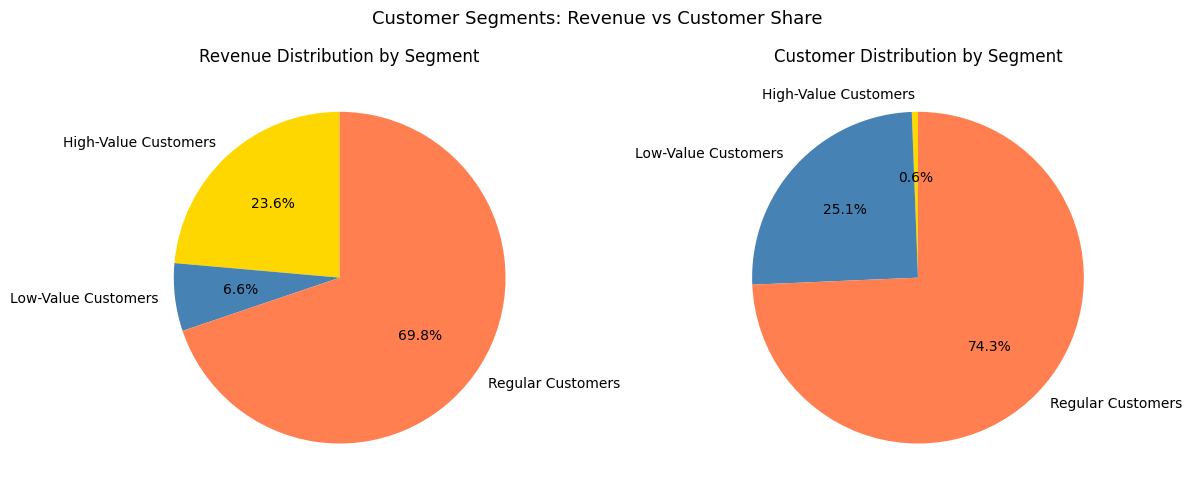

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

seg_order = ['High-Value Customers', 'Regular Customers', 'Low-Value Customers']
colors = ['gold', 'steelblue', 'coral']

# Revenue by segment
rev_data = seg_summary.loc[seg_order, 'Revenue_%'] if set(seg_order).issubset(seg_summary.index) else seg_summary['Revenue_%']
ax1.pie(seg_summary['Revenue_%'], labels=seg_summary.index, autopct='%1.1f%%',
        colors=colors[:len(seg_summary)], startangle=90)
ax1.set_title('Revenue Distribution by Segment')

# Customers by segment
ax2.pie(seg_summary['Customer_%'], labels=seg_summary.index, autopct='%1.1f%%',
        colors=colors[:len(seg_summary)], startangle=90)
ax2.set_title('Customer Distribution by Segment')

plt.suptitle('Customer Segments: Revenue vs Customer Share', fontsize=13)
plt.tight_layout()
plt.show()

## Section 3: Interactive Customer Prediction System

In [16]:
def get_better_recommendations(cart_product, rules):
    
    results = rules[
        rules['antecedents'].astype(str).str.lower().str.contains(cart_product)
    ]
    
    if results.empty:
        return results
    
    cart_words = set(cart_product.lower().split())
    
    scores = []
    
    for _, row in results.iterrows():
        rec = str(row['consequents']).lower()
        rec_words = set(rec.split())
        
        overlap = len(cart_words.intersection(rec_words))
        scores.append(overlap)
    
    results = results.copy()
    results['similarity'] = scores
    
    results = results.sort_values(
        by=['similarity','confidence','lift'], 
        ascending=[True, False, False]
    )
    
    return results


print("\n--- Customer Prediction Demo ---")

def predict_customer(customer_id, recency, frequency):
    sample = [[recency, frequency]]
    pred = model.predict(sample)[0]
    
    print(f"\nCustomer {customer_id}")
    print(f"Recency: {recency}, Frequency: {frequency}")
    print("Prediction:", "High-Value" if pred == 1 else "Low-Value")


# Demo examples
predict_customer("NEW-001", 5, 12)
predict_customer("NEW-002", 300, 1)




--- Customer Prediction Demo ---

Customer NEW-001
Recency: 5, Frequency: 12
Prediction: High-Value

Customer NEW-002
Recency: 300, Frequency: 1
Prediction: Low-Value


c:\Users\skira\Downloads\Customer_Analytics_Project\myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\skira\Downloads\Customer_Analytics_Project\myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## Section 4: Customer Interaction Demo (Console-Based)

Retrieving product recommendations for a given customer id.

In [17]:
print("Sample Customer IDs:")
print(list(segments.index)[:100])

print("\nSample Products:")
print(list(rules['antecedents'].astype(str).unique())[:100])

customer_input = input("\nEnter Customer ID: ")

if customer_input.strip() == "":
    print("No customer entered")

else:
    try:
        customer_id = int(customer_input)

        if customer_id in segments.index:
            customer = segments.loc[customer_id]

            print("\n------------------------------")
            print(f"Customer ID Entered: {customer_id}")
            print("------------------------------")

            print("\nCustomer Details:")
            print(f"Recency   : {customer['Recency']}")
            print(f"Frequency : {customer['Frequency']}")
            print(f"Monetary  : {customer['Monetary']}")
            print(f"Segment   : {customer['Segment']}")

            product_input = input("\nEnter Product Name: ").strip().lower()

            if product_input == "":
                print("No product entered")

            else:
                print("\n------------------------------")
                print(f"Product Entered: {product_input}")
                print("------------------------------")

                results = get_better_recommendations(product_input, rules)

                if results.empty:
                    print("\nNo recommendations found")

                else:
                    segment = customer['Segment']

                    if segment == "High-Value Customers":
                        results['score'] = results['lift'] * 0.7 + results['confidence'] * 0.3

                    elif segment == "Low-Value Customers":
                        results['score'] = results['confidence'] * 0.7 + results['lift'] * 0.3

                    else:
                        results['score'] = results['confidence'] * 0.5 + results['lift'] * 0.5

                    results = results.sort_values(by='score', ascending=False)

                    print("\n==============================")
                    print("PERSONALIZED RECOMMENDATIONS")
                    print("==============================")

                    print(results[['consequents','confidence','lift','score']].head())

        else:
            print("Customer ID not found")

    except:
        print("Invalid input")

Sample Customer IDs:
[12347, 12348, 12349, 12350, 12352, 12353, 12354, 12355, 12356, 12357, 12358, 12359, 12360, 12361, 12362, 12363, 12364, 12365, 12367, 12370, 12371, 12372, 12373, 12374, 12375, 12377, 12378, 12379, 12380, 12381, 12383, 12384, 12386, 12388, 12390, 12391, 12393, 12394, 12395, 12397, 12398, 12399, 12401, 12402, 12403, 12405, 12406, 12407, 12408, 12409, 12410, 12412, 12413, 12414, 12415, 12417, 12418, 12420, 12421, 12422, 12423, 12424, 12425, 12426, 12427, 12428, 12429, 12430, 12431, 12432, 12433, 12434, 12435, 12436, 12437, 12438, 12441, 12442, 12444, 12445, 12446, 12447, 12448, 12449, 12450, 12451, 12452, 12453, 12454, 12455, 12456, 12457, 12458, 12461, 12462, 12463, 12464, 12465, 12468, 12471]

Sample Products:
["frozenset({'PINK REGENCY TEACUP AND SAUCER'})", "frozenset({'ROSES REGENCY TEACUP AND SAUCER ', 'GREEN REGENCY TEACUP AND SAUCER'})", "frozenset({'GREEN REGENCY TEACUP AND SAUCER'})", "frozenset({'ROSES REGENCY TEACUP AND SAUCER ', 'PINK REGENCY TEACUP AND S

## Section 5: Full Customer Profile Integration

By combining segment data with the prediction model, we can generate a complete 360° customer profile.

In [18]:
def customer_profile(customer_id):
    """Generate a complete customer intelligence profile."""
    row = segments.loc[customer_id]
    if row.empty:
        print(f"Customer {customer_id} not found.")
        return
    
    sample = pd.DataFrame({'Recency': [row['Recency']], 'Frequency': [row['Frequency']]})
    pred = model.predict(sample)[0]
    prob = model.predict_proba(sample)[0]
    
    print(f"=== CUSTOMER PROFILE: {customer_id} ===")
    print(f"Segment:              {row['Segment']}")
    print(f"Recency:              {row['Recency']} days since last order")
    print(f"Frequency:            {row['Frequency']} orders")
    print(f"Monetary (total):     £{row['Monetary']:,.2f}")
    print(f"Model prediction:     {'High-Value' if pred == 1 else 'Low-Value'} ({max(prob)*100:.0f}% confidence)")

# Show profiles for sample customers
sample_customers = list(segments.index[:3])
for cid in sample_customers:
    customer_profile(cid)
    print()

=== CUSTOMER PROFILE: 12347 ===
Segment:              Regular Customers
Recency:              1 days since last order
Frequency:            7 orders
Monetary (total):     £4,310.00
Model prediction:     High-Value (99% confidence)

=== CUSTOMER PROFILE: 12348 ===
Segment:              Regular Customers
Recency:              74 days since last order
Frequency:            4 orders
Monetary (total):     £1,797.24
Model prediction:     High-Value (83% confidence)

=== CUSTOMER PROFILE: 12349 ===
Segment:              Regular Customers
Recency:              18 days since last order
Frequency:            1 orders
Monetary (total):     £1,757.55
Model prediction:     Low-Value (86% confidence)



## Section 6: Key Business Insights

### 6.1 Revenue Concentration
The Pareto analysis in Notebook 03 confirmed that approximately **20% of customers generate 80% of revenue**. This means:
- Losing even a handful of High-Value customers has a disproportionate revenue impact
- Retention investment is far more valuable than acquisition for this business

### 6.2 Customer Segment Strategy

| Segment | Business Action | Priority |
|---------|----------------|----------|
| **High-Value (~13 customers)** | VIP status, dedicated account manager, priority fulfilment, exclusive previews | CRITICAL |
| **Regular (~3,228 customers)** | Loyalty programme, personalised recommendations, targeted promotions | HIGH |
| **Low-Value (~1,090 customers)** | Win-back campaigns, discount offers, churn risk monitoring | MEDIUM |

### 6.3 Seasonality
Revenue peaks sharply in **November** (pre-Christmas). Actions:
- Begin outreach to Low-Value customers in September/October to re-engage before peak season
- Increase stock for top-selling products by October
- Target High-Value customers with exclusive early-access campaigns in October

### 6.4 Product Bundling Opportunity
Association rules revealed **very high lift values (>15)** for items in the Regency Teacup collection. This suggests:
- Bundle pricing (buy the set, save 10%) would likely drive higher basket values
- The recommendation system can drive cross-selling through product pages and email

### 6.5 Predictive Model Application
The 83% accurate model allows the business to:
- **Score new customers** after their first 1–2 purchases
- **Proactively assign** marketing budgets before a customer reaches High-Value status
- **Identify at-risk High-Value customers** whose Recency is increasing

## Section 7: Ethical Considerations

Data science projects carry ethical responsibilities. The following considerations are relevant to this project.

---

### 7.1 Data Privacy

**Observation:** CustomerIDs in this dataset are anonymised numeric identifiers — no personally identifiable information (PII) such as names, email addresses, or postal codes is present.

**Consideration:** The original retail customers did not explicitly consent to their transaction data being used for machine learning research or published as an open dataset. While the data is sufficiently anonymised to minimise individual privacy risk, this represents a gap in informed consent.

**Mitigation:** In a production context, customer consent and data privacy notices (e.g., GDPR compliance in the UK/EU) would be required before building ML models on transaction data.

---

### 7.2 Geographic Bias

**Observation:** Approximately **91% of transactions are from the United Kingdom**. Only ~9% represent international customers.

**Risk:** Any model or segment definition learned primarily from UK customers may not generalise to international markets. Applying the same High-Value thresholds globally could mis-classify customers from markets with different spending norms.

**Mitigation:** For international deployment, separate models should be trained on local market data, or the threshold for High-Value should be calibrated per country.

---

### 7.3 Fairness and Segment Treatment

**Observation:** Customers are labelled as 'Low-Value' based on past behaviour, not future potential.

**Risk:** If Low-Value customers are consistently deprioritised for marketing, they may never have the opportunity to become High-Value — creating a self-fulfilling prophecy that unfairly disadvantages certain customers.

**Mitigation:** Segments should be reviewed periodically (quarterly) to allow customer movement between tiers. Low-Value customers should receive relevant offers, not complete neglect. A customer who was Low-Value due to a one-off purchase may have high future potential.

---

### 7.4 Model Transparency and Explainability

**Observation:** Logistic Regression was selected specifically for its **interpretability**. Coefficients directly explain why a customer is predicted as High-Value or Low-Value.

**Why this matters:** In a retail business context, marketing teams and managers need to understand model decisions to trust and act on them. A 'black box' model (e.g., deep neural network) with similar accuracy would be harder to justify to stakeholders and regulators.

---

### 7.5 Data Security

**Good practice applied:**
- API keys are stored in a `.env` file and not committed to version control
- Customer data files are local and not shared publicly
- No PII is processed by external AI services

---

### 7.6 Temporal Validity

**Observation:** The dataset covers only December 2010 – December 2011.

**Risk:** Customer behaviour, product preferences, and market conditions change over time. A model trained on 2011 data may not accurately predict High-Value customers in 2025.

**Mitigation:** Models should be retrained regularly with fresh transaction data (e.g., annually or quarterly).

## Section 8: Technical Summary

### Dataset
- **Source**: UCI Machine Learning Repository — Online Retail Dataset
- **Size**: 541,909 raw transactions → 392,578 after cleaning
- **Period**: December 2010 – December 2011
- **Unique customers**: 4,331 (after cleaning)

### Technologies Used

| Component | Technology |
|-----------|----------|
| Data processing | Python (pandas, numpy) |
| Visualisation | matplotlib, seaborn |
| Feature engineering | StandardScaler (sklearn) |
| Clustering | KMeans (sklearn) |
| Market basket analysis | mlxtend (Apriori, association_rules) |
| Machine learning | scikit-learn, XGBoost |
| Model persistence | joblib |
| Interactive dashboard | Streamlit |
| AI chatbot integration | OpenAI GPT-4o-mini |

### Model Performance

| Metric | Value |
|--------|-------|
| Algorithm | Logistic Regression |
| Train/Test split | 80/20 |
| Accuracy | ~83% |
| AUC-ROC | ~0.90 |
| F1 Score (High-Value) | ~0.83 |

## Section 9: Project Conclusion

This project successfully built an **end-to-end customer analytics pipeline** on the UCI Online Retail dataset, progressing from raw transaction data to a production-ready Streamlit dashboard.

### What was achieved

1. **Data Pipeline**: Cleaned 541,909 transactions → 392,578 valid records through principled, documented decisions

2. **EDA**: Identified clear seasonality, Pareto revenue concentration, and geographic skew — all of which inform business strategy

3. **RFM Segmentation**: Classified 4,331 customers into 3 meaningful segments (High-Value, Regular, Low-Value) using K-Means clustering, providing actionable targeting guidance

4. **Recommendation System**: Discovered strong product associations (lift > 15) using Apriori, enabling data-driven cross-selling and bundle recommendations

5. **Predictive Model**: Trained a Logistic Regression classifier achieving **83% accuracy** and **AUC ~0.90** for High-Value customer identification — deployable at scale

6. **Streamlit Dashboard**: Integrated all outputs into an interactive application with customer lookup, segment visualisation, product recommendations, and AI-powered Q&A

### Business Value

The system enables the retailer to move from **reactive** to **proactive** customer management:
- Identify which customers need retention attention **before** they churn
- Personalise product recommendations at scale without manual effort  
- Allocate marketing budget based on predicted customer lifetime value
- Monitor seasonal patterns and prepare stock/campaigns accordingly

### Limitations and Future Work

| Limitation | Future Improvement |
|-----------|--------------------|
| Only 1 year of data | Retrain on multi-year data for better seasonality modelling |
| 91% UK customers | Build country-specific models for international deployment |
| Binary classification only | Extend to multi-class or regression for precise lifetime value prediction |
| Top-100 products for Apriori | Use collaborative filtering on full catalogue |
| Static segments | Implement dynamic, real-time segment updating as new transactions arrive |